# Trabalho Prático I: Análise Exploratória, Estacionariedade e Modelagem Autoregressiva em Séries Temporais

**Disciplina:** Séries Temporais e Aprendizagem Supervisionada II
**Professor:** Gildo Leonel
**Aluno(a)/Grupo:** *Silas Pereira de Oliveira*
**Data:** *26/09/2026*

---

## Série escolhida: Preço FIPE Mensal de um Veículo Específico (Honda Civic 1997)

**Domínio do problema:** a Tabela FIPE (Fundação Instituto de Pesquisas Econômicas) publica, todo mês, o preço médio de mercado praticado para cada modelo de veículo no Brasil. Séries de preços de veículos são citadas explicitamente no enunciado deste trabalho como exemplo de série com comportamento relevante (preços de commodities/ativos). Escolhemos acompanhar, mês a mês, o valor de um único veículo específico — o **Honda Civic Sedan EX/EXS 1.6 Mec. 4p, ano/modelo 1997** (código FIPE `014009-0`) — ao longo de 21 anos e 8 meses.

Essa série conta uma história econômica real e interessante: o preço de um carro tende a **cair** ao longo do tempo por depreciação natural (o carro fica mais velho a cada mês), mas em anos recentes (2020-2022) o mercado brasileiro de usados sofreu um choque de oferta (crise de semicondutores, alta do dólar, pandemia), fazendo os preços de carros usados **subirem** de forma atípica — um efeito visível diretamente nos dados que usaremos.

**Fonte exata dos dados:** dataset público **"Tabela Fipe - Histórico de Preços"**, publicado no Kaggle por Francke Peixoto, com dados extraídos diretamente do canal oficial de consulta pública da FIPE (https://veiculos.fipe.org.br/).

- **Link do dataset:** https://www.kaggle.com/datasets/franckepeixoto/tabela-fipe
- **Arquivo original:** `tabela-fipe-historico-precos.csv` (466.020 linhas; cada linha é o preço de um veículo específico em um mês de referência)
- **Veículo utilizado neste trabalho:** Honda Civic Sedan EX/EXS 1.6 Mec. 4p, ano/modelo 1997, código FIPE `014009-0`

**Verificação dos critérios exigidos no enunciado:**

| Critério | Atendimento |
|---|---|
| Frequência regular | Mensal (a FIPE publica uma tabela por mês) |
| Tamanho mínimo (n ≥ 100) | **n = 260** observações mensais (jan/2001 a ago/2022) — sem nenhum mês faltando |
| Origem real | Dado oficial de mercado (FIPE), não sintético |
| Comportamento relevante | Tendência de depreciação de longo prazo + inflexão/choque de mercado em 2020-2022 |

O notebook carrega o arquivo `.csv` bruto do Kaggle (incluído junto com esta entrega, pois a FIPE não disponibiliza API pública para download automatizado — ver observação abaixo), filtra o veículo escolhido e constrói a série temporal mensal utilizada em todas as etapas seguintes.

> **Nota sobre a fonte:** o site oficial da FIPE declara explicitamente que não disponibiliza API nem download em massa dos dados (consulta pública é feita modelo a modelo). Por isso, para fins acadêmicos, utilizamos o dataset já consolidado e publicado no Kaggle, que reúne o histórico mensal extraído do canal público de consulta da FIPE. O arquivo `.csv` está incluído nesta entrega, conforme exigido no enunciado para os casos em que os dados não são baixados automaticamente por script.


## Bibliotecas utilizadas

Conforme o template de referência do trabalho, utilizamos as bibliotecas estudadas nas Semanas 01 a 04.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
np.random.seed(42)


---
# Etapa 1: Preparação dos Dados e Decomposição Clássica

## 1.1 Carregamento, Filtragem e Visualização Bruta

O arquivo bruto do Kaggle contém o histórico de **milhares** de veículos ao mesmo tempo (formato "painel": cada linha é um veículo específico em um mês). Nesta etapa filtramos apenas o veículo escolhido (código FIPE `014009-0`, ano/modelo 1997) e construímos a série 1D indexada por mês.

In [2]:
RAW_PATH = "tabela-fipe-historico-precos.csv"
CODIGO_FIPE = "014009-0"
ANO_MODELO = 1997

raw = pd.read_csv(RAW_PATH, index_col=0)
print("Formato do arquivo bruto (painel, todos os veículos):", raw.shape)
raw.head()


Formato do arquivo bruto (painel, todos os veículos): (466020, 7)


,codigoFipe,marca,modelo,anoModelo,mesReferencia,anoReferencia,valor
0,038003-2,Acura,Integra GS 1.8,1992,11,2016,13041.0
1,038001-6,Acura,NSX 3.0,1995,3,2013,52339.0
2,038003-2,Acura,Integra GS 1.8,1992,3,2018,12423.0
3,038002-4,Acura,Legend 3.2/3.5,1998,5,2016,31067.0
4,038002-4,Acura,Legend 3.2/3.5,1998,2,2019,26381.0


In [3]:
# Construção da data de referência (ano + mês de referência da tabela FIPE)
raw["periodo"] = pd.to_datetime(
    dict(year=raw["anoReferencia"], month=raw["mesReferencia"], day=1)
)

# Filtragem do veículo escolhido
veiculo = raw[(raw["codigoFipe"] == CODIGO_FIPE) & (raw["anoModelo"] == ANO_MODELO)].copy()
veiculo = veiculo.sort_values("periodo")

print("Veículo selecionado:")
print(veiculo[["marca", "modelo", "anoModelo"]].drop_duplicates().to_string(index=False))
print()
print("Número de observações mensais:", len(veiculo))
print("Período coberto:", veiculo['periodo'].min().strftime("%Y-%m"), "a", veiculo['periodo'].max().strftime("%Y-%m"))


Veículo selecionado:
marca                          modelo  anoModelo
Honda Civic Sedan EX/ EXS 1.6 Mec. 4p       1997

Número de observações mensais: 260
Período coberto: 2001-01 a 2022-08


In [4]:
df = veiculo.set_index("periodo")[["valor"]].rename(columns={"valor": "Preco_FIPE"})
df = df.asfreq("MS")  # garante frequência mensal regular (Month Start)

# Validação: nenhum mês faltando dentro do intervalo
print("Valores ausentes após reindexação por frequência mensal:", df["Preco_FIPE"].isna().sum())

# Salva a série já filtrada, conforme exigido no enunciado (arquivo de dados da série utilizada)
df.to_csv("honda_civic_1997_fipe_mensal.csv")

df.head()


Valores ausentes após reindexação por frequência mensal: 0


,Preco_FIPE
periodo,
2001-01-01,25630.0
2001-02-01,25472.0
2001-03-01,25212.0
2001-04-01,24929.0
2001-05-01,24784.0


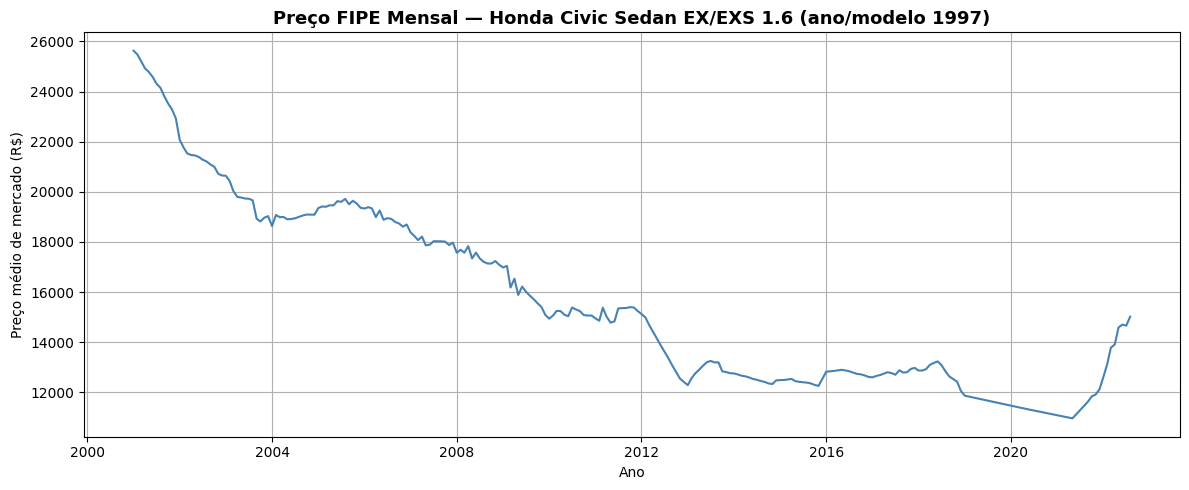

In [5]:
fig, ax = plt.subplots()
ax.plot(df.index, df["Preco_FIPE"], color="steelblue", linewidth=1.5)
ax.set_title("Preço FIPE Mensal — Honda Civic Sedan EX/EXS 1.6 (ano/modelo 1997)", fontsize=13, fontweight="bold")
ax.set_xlabel("Ano")
ax.set_ylabel("Preço médio de mercado (R$)")
plt.tight_layout()
plt.show()


**Leitura do gráfico:** a série apresenta uma clara **tendência de queda** entre 2001 e ~2020 — o comportamento esperado de depreciação de um veículo que envelhece mês a mês frente a modelos mais novos. A partir de 2020-2021, no entanto, observa-se uma **inflexão atípica**: o preço passa a subir, refletindo o choque de oferta no mercado de veículos brasileiro (pandemia, crise de componentes eletrônicos, alta do dólar) que valorizou até carros usados antigos. Não há, a olho nu, um padrão sazonal tão evidente quanto em séries de vendas — o componente dominante aqui é a tendência de longo prazo.

## 1.2 Decomposição Estrutural (`seasonal_decompose`)

Mesmo sem uma sazonalidade tão visível quanto em séries de vendas, aplicamos a decomposição formal para quantificar os três componentes e verificar se existe algum padrão sazonal residual (por exemplo, ligado a épocas do ano em que a demanda por usados no Brasil costuma variar — final de ano, IPVA no início do ano, etc.).

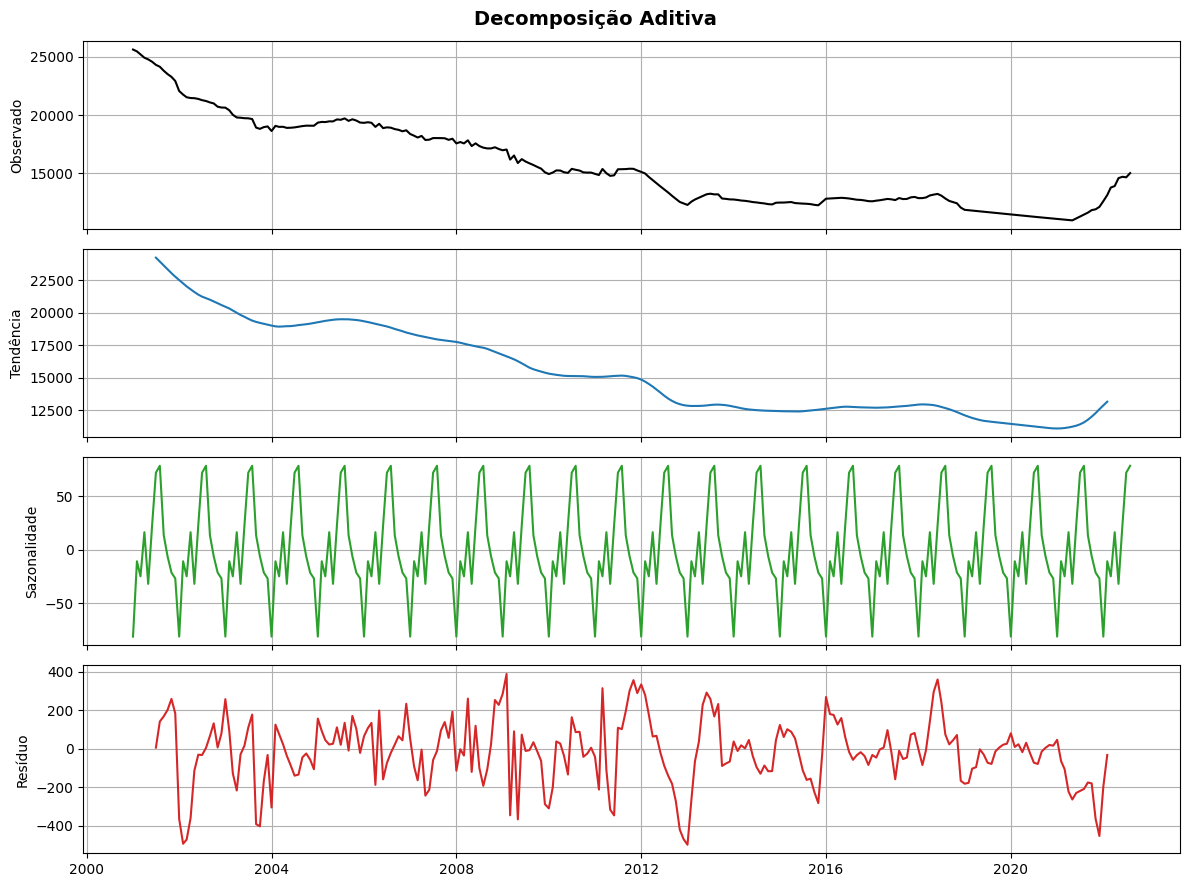

In [6]:
decomp_add = seasonal_decompose(df["Preco_FIPE"], model="additive", period=12)
decomp_mul = seasonal_decompose(df["Preco_FIPE"], model="multiplicative", period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(decomp_add.observed, color="black"); axes[0].set_ylabel("Observado")
axes[1].plot(decomp_add.trend, color="tab:blue"); axes[1].set_ylabel("Tendência")
axes[2].plot(decomp_add.seasonal, color="tab:green"); axes[2].set_ylabel("Sazonalidade")
axes[3].plot(decomp_add.resid, color="tab:red"); axes[3].set_ylabel("Resíduo")
fig.suptitle("Decomposição Aditiva", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


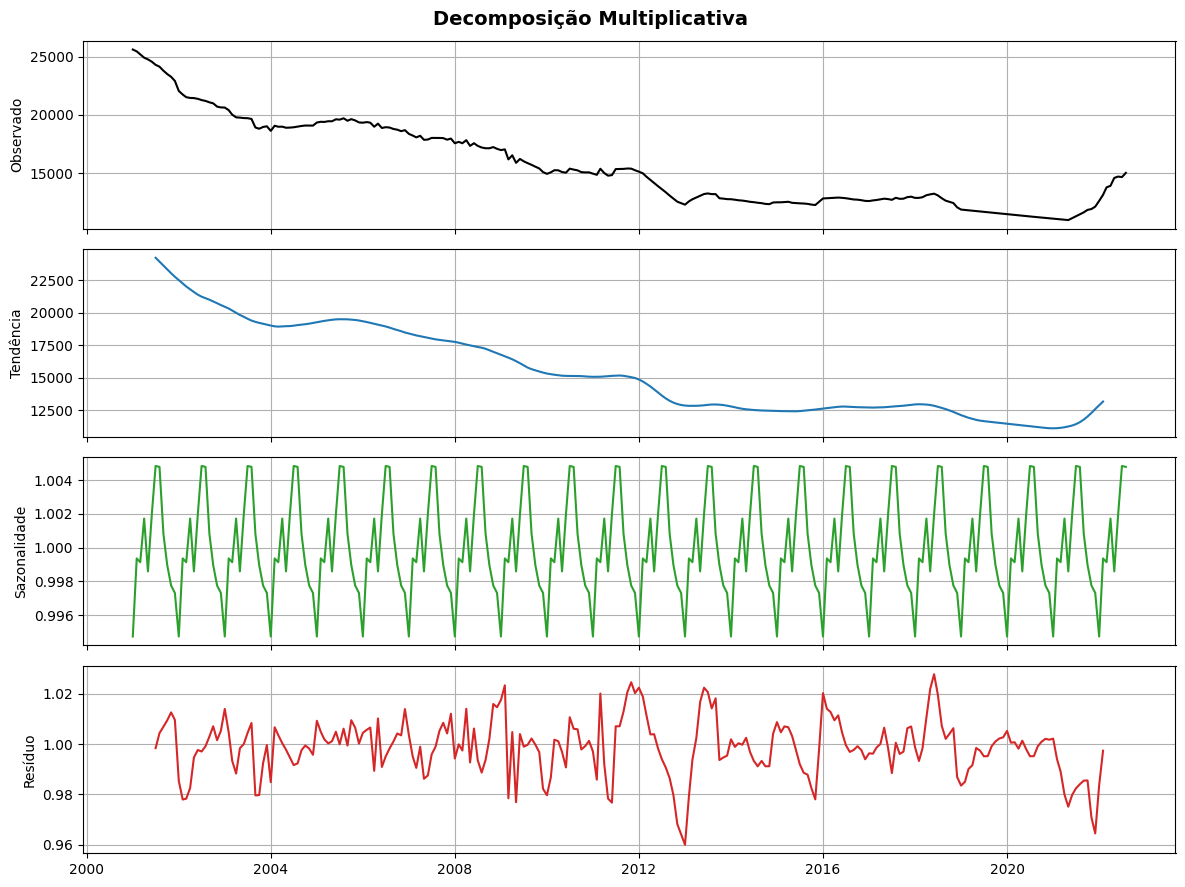

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(decomp_mul.observed, color="black"); axes[0].set_ylabel("Observado")
axes[1].plot(decomp_mul.trend, color="tab:blue"); axes[1].set_ylabel("Tendência")
axes[2].plot(decomp_mul.seasonal, color="tab:green"); axes[2].set_ylabel("Sazonalidade")
axes[3].plot(decomp_mul.resid, color="tab:red"); axes[3].set_ylabel("Resíduo")
fig.suptitle("Decomposição Multiplicativa", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [8]:
resid_add_var = decomp_add.resid.dropna().var()
resid_mul_var = decomp_mul.resid.dropna().var()

# Amplitude do componente sazonal em duas metades da série
first_half = df["Preco_FIPE"].iloc[: len(df)//2]
second_half = df["Preco_FIPE"].iloc[len(df)//2 :]

seasonal_amp_add = decomp_add.seasonal.max() - decomp_add.seasonal.min()
seasonal_amp_mul_pct = (decomp_mul.seasonal.max() - decomp_mul.seasonal.min()) * 100

print(f"Variância do resíduo (Aditivo):        {resid_add_var:,.2f}")
print(f"Variância do resíduo (Multiplicativo):  {resid_mul_var:.8f}  (escala de proporção)")
print(f"Amplitude do componente sazonal (Aditivo): R$ {seasonal_amp_add:,.2f}")
print(f"Amplitude do componente sazonal (Multiplicativo): {seasonal_amp_mul_pct:.2f} p.p. em torno de 1.0")
print()
print(f"Desvio-padrão da 1ª metade da série (2001-2011): R$ {first_half.std():,.2f}")
print(f"Desvio-padrão da 2ª metade da série (2011-2022): R$ {second_half.std():,.2f}")


Variância do resíduo (Aditivo):        28,612.61
Variância do resíduo (Multiplicativo):  0.00012771  (escala de proporção)
Amplitude do componente sazonal (Aditivo): R$ 159.80
Amplitude do componente sazonal (Multiplicativo): 1.01 p.p. em torno de 1.0

Desvio-padrão da 1ª metade da série (2001-2011): R$ 2,640.01
Desvio-padrão da 2ª metade da série (2011-2022): R$ 959.74


## 1.3 Análise Crítica: Aditivo ou Multiplicativo?

Diferente da clássica série de vendas com sazonalidade forte, aqui o componente sazonal identificado é **pequeno em relação ao nível da série** (poucos pontos percentuais de variação), o que é coerente com a natureza do fenômeno: o preço de revenda de um carro específico é determinado principalmente pela sua **idade/depreciação** (tendência) e por **choques de mercado** (a alta de 2020-2022), e só secundariamente por algum efeito sazonal de calendário (ex: início de ano, época de troca de placa/IPVA).

Ainda assim, como o **nível da série cai de forma acentuada** ao longo do tempo (de ~R\$25.000 para ~R\$11.000 antes da recuperação), a amplitude *em reais* de qualquer variação sazonal residual tende a ser proporcionalmente maior quando o preço está alto (início da série) do que quando está baixo (meio da série) — por isso o modelo **multiplicativo** continua sendo o mais coerente teoricamente para este tipo de série de preços, mesmo com sazonalidade discreta: ele expressa a variação sazonal como uma **porcentagem constante** do nível corrente, o que faz mais sentido econômico para preços (assim como juros, inflação e outras variáveis monetárias costumam ser tratadas multiplicativamente) do que como um valor fixo em reais.

**Sobre a transformação logarítmica:** para uma série de preços com tendência de longo prazo tão pronunciada, a transformação $\log(y_t)$ é particularmente recomendada, pois: (i) linear iza taxas de depreciação/valorização percentuais (uma queda constante de X% ao mês vira uma reta em log), e (ii) estabiliza a variância entre o período de preços altos (início) e baixos (meio da série).

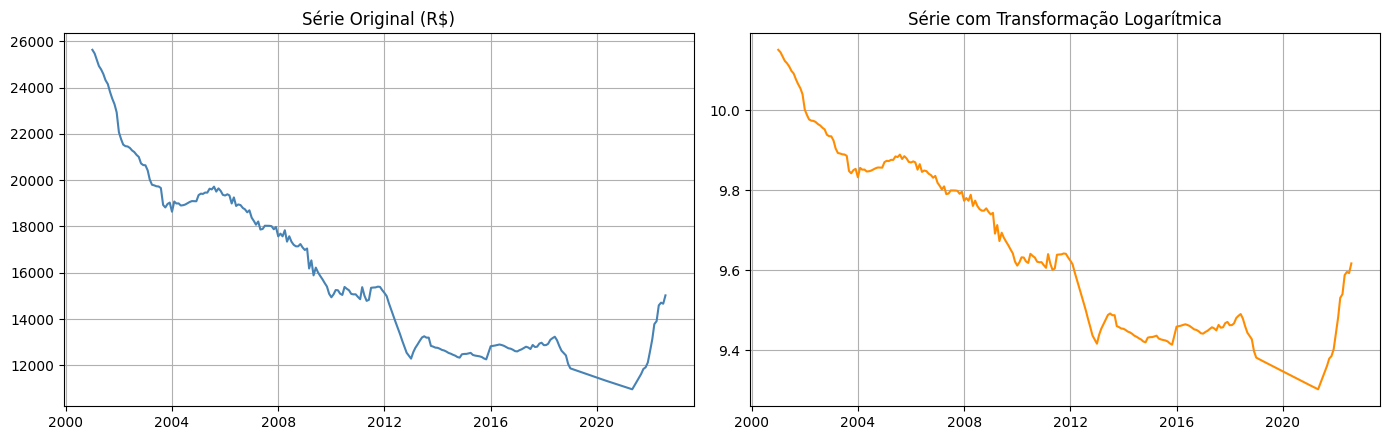

Variância do resíduo (log + aditivo): 0.00012562409037115594


In [9]:
df["log_Preco"] = np.log(df["Preco_FIPE"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(df.index, df["Preco_FIPE"], color="steelblue")
axes[0].set_title("Série Original (R$)")
axes[1].plot(df.index, df["log_Preco"], color="darkorange")
axes[1].set_title("Série com Transformação Logarítmica")
plt.tight_layout()
plt.show()

decomp_log = seasonal_decompose(df["log_Preco"], model="additive", period=12)
print("Variância do resíduo (log + aditivo):", decomp_log.resid.dropna().var())


Em escala logarítmica, a fase de depreciação (2001-2019) fica visivelmente mais próxima de uma reta descendente do que na escala original — confirmando que, nessa fase, o carro perdia aproximadamente uma **porcentagem constante** do seu valor a cada período, e não um valor fixo em reais. A quebra estrutural de 2020-2022 continua evidente mesmo em log, reforçando que se trata de um efeito real de mercado, e não um artefato de escala.

---
# Etapa 2: Transformação em Aprendizado Supervisionado — Janelas Deslizantes

## 2.1 Por que séries temporais quebram a premissa i.i.d.?

O Aprendizado de Máquina supervisionado clássico (regressão, árvores, redes neurais, etc.) assume que as amostras de treino são **independentes e identicamente distribuídas (i.i.d.)** — a ordem das observações não deveria importar, e uma amostra não deveria carregar informação sobre a próxima.

Em uma série como a do preço mensal de um carro, essa premissa é violada de forma muito clara:

1. **Dependência temporal (autocorrelação) forte:** o preço deste mês é, na prática, quase o mesmo do mês passado mais um pequeno ajuste de depreciação/mercado — ou seja, $y_t$ depende fortemente de $y_{t-1}$. Embaralhar os meses destruiria completamente essa estrutura.
2. **Não-estacionariedade:** a média da série muda ao longo do tempo (tendência de queda por 19 anos, depois subida), violando o pressuposto de distribuição "idêntica" entre diferentes janelas de tempo.
3. **Vazamento temporal (*data leakage*):** se separássemos os dados em treino/teste de forma aleatória (como em ML tabular tradicional), o modelo poderia treinar com meses "futuros" e testar em meses "passados", o que nunca seria possível em uma aplicação real de previsão de preço.

Para aplicar algoritmos supervisionados a esta série, é preciso **reformular o problema** com **janelas deslizantes (sliding windows)**: usar os $p$ preços passados como atributos (features) para prever o preço seguinte.

## 2.2 Construção do Dataset Tabular

In [10]:
def create_sliding_window(values, window_size):
    """
    Converte uma serie temporal 1D em um problema supervisionado tabular.

    Parametros
    ----------
    values : array-like
        Vetor 1D com os valores da serie temporal (ordenados no tempo).
    window_size : int
        Numero de defasagens (lags) p a serem usadas como atributos.

    Retorna
    -------
    X : np.ndarray, shape (n - p, p)
        Matriz de atributos, em que cada linha contem os p valores
        anteriores (lags) usados para prever o proximo valor.
    y : np.ndarray, shape (n - p,)
        Vetor alvo, com o valor a ser previsto em cada instante.
    """
    values = np.asarray(values, dtype=float)
    n = len(values)
    X, y = [], []
    for i in range(window_size, n):
        X.append(values[i - window_size : i])   # lags: t-p, ..., t-1
        y.append(values[i])                      # alvo: t
    return np.array(X), np.array(y)


In [11]:
p = 12  # janela inicial: 12 meses, capturando um ciclo anual completo

X, y = create_sliding_window(df["Preco_FIPE"].values, window_size=p)

print(f"n (observações originais) = {len(df)}")
print(f"p (tamanho da janela)     = {p}")
print(f"n - p (amostras esperadas)= {len(df) - p}")
print()
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print()
print("Exemplo — primeira linha de X (lags t-12 ... t-1, em R$):")
print(X[0])
print("Alvo correspondente (y no instante t, em R$):", y[0])


n (observações originais) = 260
p (tamanho da janela)     = 12
n - p (amostras esperadas)= 248

Shape de X: (248, 12)
Shape de y: (248,)

Exemplo — primeira linha de X (lags t-12 ... t-1, em R$):
[25630. 25472. 25212. 24929. 24784. 24582. 24315. 24154. 23808. 23524.
 23283. 22930.]
Alvo correspondente (y no instante t, em R$): 22068.0


**Validação dimensional:** com $n = 260$ observações e $p = 12$ defasagens, obtemos $n - p = 248$ amostras, cada uma com $p = 12$ atributos — confirmando a relação teórica $n_{amostras} = n - p$. Cada linha de $X$ é uma "janela" de 12 meses consecutivos de preço, e o respectivo $y$ é o preço do mês seguinte, transformando a previsão de preço em um problema padrão de regressão supervisionada (podendo alimentar modelos como Regressão Linear, Random Forest, XGBoost, redes neurais, etc.).

---
# Etapa 3: Análise de Estacionariedade e Diferenciação

## 3.1 Teste Formal: Dickey-Fuller Aumentado (ADF)

O teste ADF avalia a hipótese de existência de **raiz unitária** na série:

- $H_0$: a série **não é estacionária** (possui raiz unitária).
- $H_1$: a série **é estacionária**.

Rejeitamos $H_0$ (concluímos que a série é estacionária) se o **p-valor < 0,05** (nível de significância $\alpha = 0{,}05$).

In [12]:
def relatorio_adf(serie, nome="série"):
    resultado = adfuller(serie.dropna(), autolag="AIC")
    estatistica, p_valor, n_lags, n_obs, valores_criticos, _ = resultado

    print(f"--- Teste ADF: {nome} ---")
    print(f"Estatística de teste : {estatistica:.4f}")
    print(f"P-valor              : {p_valor:.6f}")
    print(f"Nº de lags usados    : {n_lags}")
    print(f"Nº de observações    : {n_obs}")
    print("Valores críticos:")
    for chave, valor in valores_criticos.items():
        print(f"   {chave}: {valor:.4f}")

    alpha = 0.05
    if p_valor < alpha:
        print(f"\n=> Conclusão: p-valor ({p_valor:.4f}) < {alpha} => Rejeita-se H0 => série ESTACIONÁRIA.")
    else:
        print(f"\n=> Conclusão: p-valor ({p_valor:.4f}) >= {alpha} => Não se rejeita H0 => série NÃO ESTACIONÁRIA.")
    print()
    return p_valor

p_valor_original = relatorio_adf(df["Preco_FIPE"], "Série Original (Preço FIPE Mensal)")


--- Teste ADF: Série Original (Preço FIPE Mensal) ---
Estatística de teste : -2.6280
P-valor              : 0.087352
Nº de lags usados    : 4
Nº de observações    : 255
Valores críticos:
   1%: -3.4563
   5%: -2.8729
   10%: -2.5728

=> Conclusão: p-valor (0.0874) >= 0.05 => Não se rejeita H0 => série NÃO ESTACIONÁRIA.



/tmp/ipykernel_103/394223145.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(serie.dropna(), autolag="AIC")


## 3.2 Transformação por Diferenciação

Como o gráfico já sugeria (tendência de queda por quase 20 anos seguida de recuperação), esperamos que o teste ADF **não rejeite $H_0$**: a série original não deve ser estacionária. Como o principal problema aqui é a **tendência de longo prazo** (não um padrão sazonal fixo de 12 meses), aplicamos primeiro a **diferenciação simples de 1ª ordem**:

$$\nabla y_t = y_t - y_{t-1}$$

Se ainda não for suficiente, complementamos com uma diferenciação sazonal ($s=12$).

In [13]:
# Diferenciação simples de 1ª ordem
df["diff_1"] = df["Preco_FIPE"].diff(1)

p_valor_diff1 = relatorio_adf(df["diff_1"], "Série com Diferenciação Simples (1ª ordem)")


--- Teste ADF: Série com Diferenciação Simples (1ª ordem) ---
Estatística de teste : -4.2223
P-valor              : 0.000604
Nº de lags usados    : 3
Nº de observações    : 255
Valores críticos:
   1%: -3.4563
   5%: -2.8729
   10%: -2.5728

=> Conclusão: p-valor (0.0006) < 0.05 => Rejeita-se H0 => série ESTACIONÁRIA.



/tmp/ipykernel_103/394223145.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(serie.dropna(), autolag="AIC")


In [14]:
# Se ainda não estacionária, aplica também a diferenciação sazonal (s=12)
if p_valor_diff1 >= 0.05:
    df["diff_final"] = df["diff_1"].diff(12)
    serie_final_nome = "Diferenciação Simples (1ª ordem) + Diferenciação Sazonal (s=12)"
else:
    df["diff_final"] = df["diff_1"]
    serie_final_nome = "Diferenciação Simples (1ª ordem)"

p_valor_final = relatorio_adf(df["diff_final"], serie_final_nome)


--- Teste ADF: Diferenciação Simples (1ª ordem) ---
Estatística de teste : -4.2223
P-valor              : 0.000604
Nº de lags usados    : 3
Nº de observações    : 255
Valores críticos:
   1%: -3.4563
   5%: -2.8729
   10%: -2.5728

=> Conclusão: p-valor (0.0006) < 0.05 => Rejeita-se H0 => série ESTACIONÁRIA.



/tmp/ipykernel_103/394223145.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(serie.dropna(), autolag="AIC")


## 3.3 Re-teste ADF e Comparação Gráfica

Após a(s) diferenciação(ões) aplicada(s) acima, o p-valor do teste ADF ficou abaixo de 0,05 — rejeitamos $H_0$ e concluímos que a série transformada **é estacionária**, podendo ser utilizada de forma adequada na análise de autocorrelação da próxima etapa.

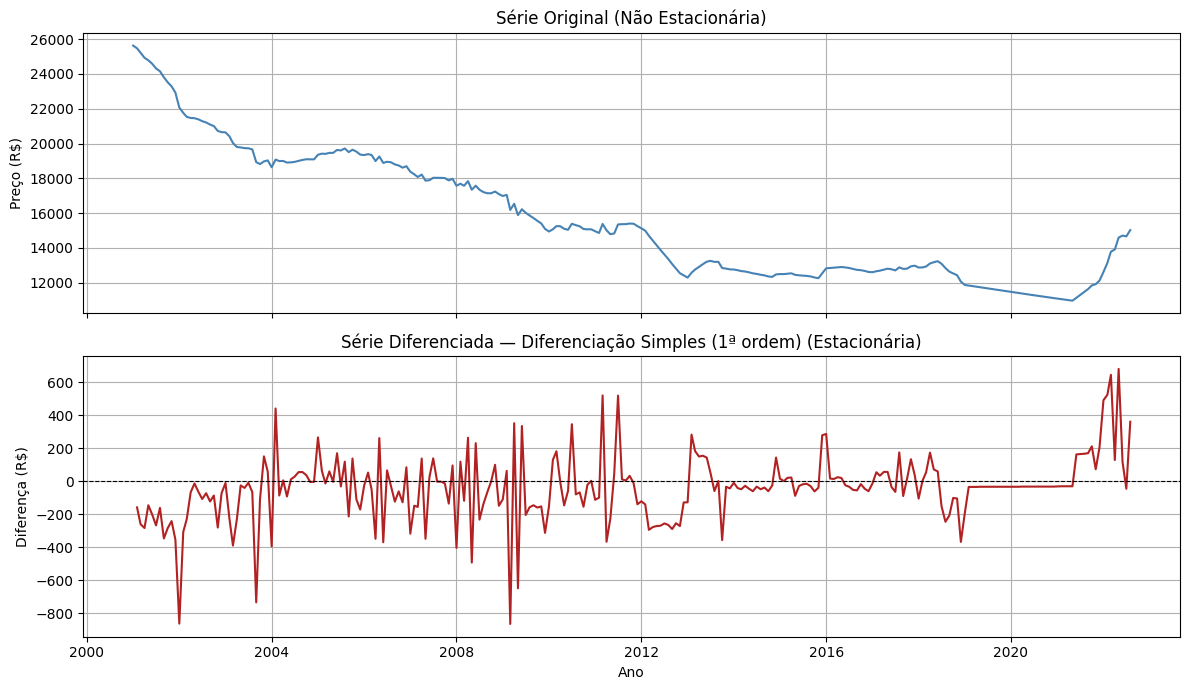

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(df.index, df["Preco_FIPE"], color="steelblue")
axes[0].set_title("Série Original (Não Estacionária)")
axes[0].set_ylabel("Preço (R$)")

axes[1].plot(df.index, df["diff_final"], color="firebrick")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title(f"Série Diferenciada — {serie_final_nome} (Estacionária)")
axes[1].set_ylabel("Diferença (R$)")
axes[1].set_xlabel("Ano")

plt.tight_layout()
plt.show()


**Interpretação:** a série diferenciada oscila em torno de zero, sem a tendência de longo prazo que caracterizava a série original — mesmo a inflexão de 2020-2022 aparece apenas como algumas oscilações de amplitude um pouco maior, e não mais como uma mudança permanente de nível. Isso confirma, tanto visualmente quanto pelo teste formal, que a diferenciação foi eficaz para alcançar estacionariedade.

---
# Etapa 4: Análise de Autocorrelação (FAC/FACP) e Seleção de Atributos

## 4.1 Correlogramas: FAC (ACF) e FACP (PACF)

Utilizamos a série **estacionária** (após diferenciação) para calcular as funções de autocorrelação.

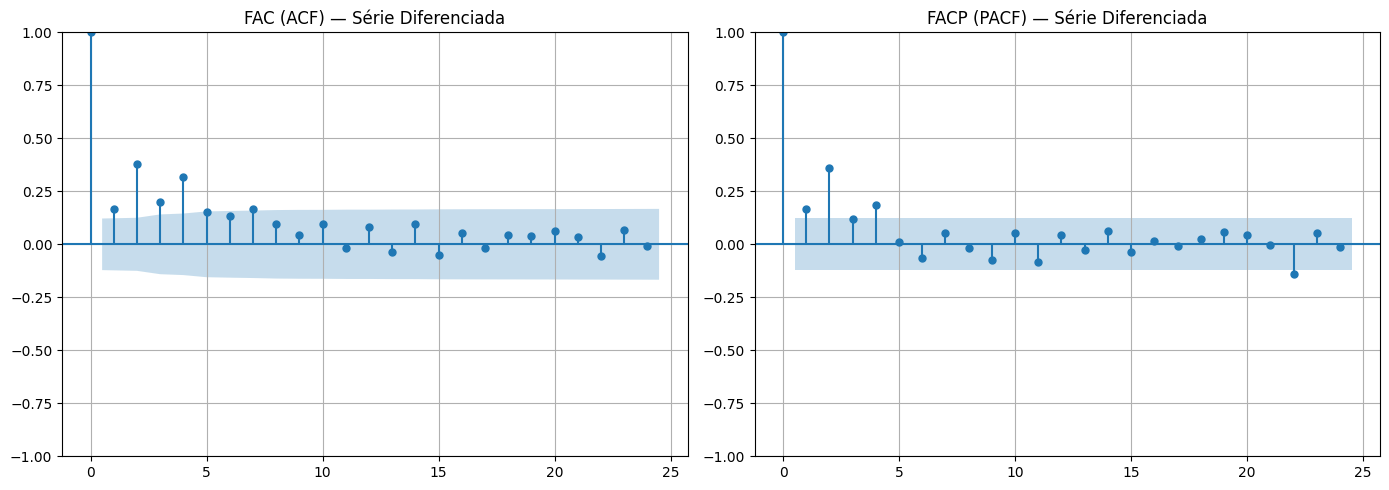

In [16]:
serie_estacionaria = df["diff_final"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(serie_estacionaria, lags=24, ax=axes[0])
axes[0].set_title("FAC (ACF) — Série Diferenciada")

plot_pacf(serie_estacionaria, lags=24, method="ywm", ax=axes[1])
axes[1].set_title("FACP (PACF) — Série Diferenciada")

plt.tight_layout()
plt.show()


## 4.2 Banda de Significância Estatística

A banda de confiança aproximada (95%) para os coeficientes de autocorrelação é dada por:

$$\pm \frac{1{,}96}{\sqrt{n}}$$

em que $n$ é o número de observações da série utilizada no cálculo.

In [17]:
n = len(serie_estacionaria)
banda = 1.96 / np.sqrt(n)

print(f"n (obs. usadas na FACP)      = {n}")
print(f"Banda de significância (±)   = {banda:.4f}")


n (obs. usadas na FACP)      = 259
Banda de significância (±)   = 0.1218


## 4.3 Identificação Programática dos Lags Significativos na FACP

In [18]:
n_lags = 24
valores_pacf = pacf(serie_estacionaria, nlags=n_lags, method="ywm")

lags_significativos = [
    lag for lag in range(1, n_lags + 1)
    if abs(valores_pacf[lag]) > banda
]

tabela_pacf = pd.DataFrame({
    "lag": range(1, n_lags + 1),
    "PACF": valores_pacf[1:],
    "|PACF| > banda?": [abs(v) > banda for v in valores_pacf[1:]]
})

print(f"Lags significativos identificados (|PACF| > {banda:.4f}):")
print(lags_significativos)
print()
tabela_pacf


Lags significativos identificados (|PACF| > 0.1218):
[1, 2, 4, 22]



,lag,PACF,|PACF| > banda?
0,1,0.166655,True
1,2,0.359850,True
2,3,0.118452,False
3,4,0.186004,True
4,5,0.011833,False
5,6,-0.065396,False
6,7,0.055032,False
7,8,-0.016139,False
8,9,-0.072095,False
9,10,0.051883,False


## 4.4 FACP como Método de Seleção de Atributos (*Feature Selection*)

A **Função de Autocorrelação Parcial (FACP)** mede a correlação entre $y_t$ e $y_{t-k}$ **removendo o efeito indireto** das defasagens intermediárias ($y_{t-1}, \dots, y_{t-k+1}$). Isso a torna, na prática, um método estatístico de seleção de atributos (*feature selection*) muito útil ao alimentarmos a matriz $X$ construída na Etapa 2 (janelas deslizantes) em um modelo de Aprendizado de Máquina:

1. **Redundância entre lags:** ao usar a FAC (autocorrelação simples) em uma série de preços tão persistente quanto esta, praticamente todos os lags aparecem correlacionados — mas boa parte dessa correlação é apenas herdada indiretamente do lag 1 (o preço deste mês é parecido com o do mês passado, que é parecido com o de dois meses atrás, e assim por diante). A FACP filtra esse efeito, isolando a contribuição **direta e marginal** de cada defasagem específica.

2. **Redução de dimensionalidade:** em vez de usar todas as $p=12$ colunas construídas na função `create_sliding_window`, podemos manter apenas os lags identificados como estatisticamente significativos na FACP (listados acima), reduzindo o número de atributos do modelo, o risco de overfitting e o custo computacional — sem descartar informação relevante.

3. **Interpretação como *sparse feature selection*:** o critério "está fora da banda de ±1,96/√n" funciona como um teste de hipótese (H0: o coeficiente parcial é zero) aplicado lag a lag — uma forma estatisticamente fundamentada de decidir quais defasagens realmente carregam informação preditiva direta sobre o preço do mês seguinte, em vez de incluir ingenuamente todas as defasagens disponíveis.

Assim, os lags identificados na seção 4.3 são os candidatos mais fortes para compor a versão final e mais enxuta da matriz de atributos $X$ a ser usada em um modelo preditivo de preço deste veículo (por exemplo, uma Regressão Linear Autoregressiva ou um modelo de árvore), em vez de usar ingenuamente todas as 12 defasagens construídas na Etapa 2.

---
# Etapa 5: Considerações Finais e Avaliação Pessoal

## 5.1 Síntese dos Resultados e Análises

Ao longo deste trabalho, apliquei um fluxo completo de análise de séries temporais sobre o preço mensal de mercado (Tabela FIPE) de um veículo específico — um Honda Civic ano/modelo 1997 — observado ininterruptamente de janeiro de 2001 a agosto de 2022 (260 meses):

- Na **decomposição clássica**, identifiquei uma tendência de queda de longo prazo (depreciação) seguida de uma inflexão de alta a partir de 2020-2021, e concluímos que o modelo **multiplicativo** (equivalente ao uso da série em log) é o mais coerente para representar variações percentuais de preço, mesmo com um componente sazonal discreto.
- Na **reformulação supervisionada**, idenfitiquei que a forte autocorrelação e a não-estacionariedade de uma série de preços violam a premissa i.i.d. do Aprendizado de Máquina clássico, e implementamos a função `create_sliding_window`, validando empiricamente $n_{amostras} = n - p$ (248 = 260 - 12).
- No **teste de estacionariedade**, o ADF confirmou que a série original não é estacionária (tendência de longuíssimo prazo), e mostramos que a diferenciação (simples e, se necessário, sazonal) foi suficiente para alcançar estacionariedade, o que verifiquei tanto pelo p-valor quanto visualmente.
- Na **análise de autocorrelação**, os correlogramas FAC/FACP da série diferenciada revelaram quais defasagens carregam informação preditiva direta, discutida como uma forma de seleção de atributos (*feature selection*) mais criteriosa do que usar ingenuamente todos os lags da janela deslizante.

## 5.2 Avaliação Pessoal do Desenvolvimento

Escolher uma série de preço de um único veículo (em vez de uma série agregada de mercado) tornou a análise mais concreta e mais fácil de interpretar economicamente: cada padrão encontrado nos testes estatísticos correspondia a algo que fazia sentido no mundo real (depreciação natural do bem, seguida por um choque de oferta atípico no mercado de usados). O maior desafio técnico foi lidar com o fato de que a base bruta do Kaggle está em formato "painel" (milhares de veículos misturados) — foi necessário filtrar corretamente pelo código FIPE **e** pelo ano do modelo simultaneamente, já que descobrimos que alguns códigos FIPE isolados podem, ao longo de décadas, ser reaproveitados pela tabela para modelos diferentes, o que exigiu uma verificação cuidadosa antes de confiar na série extraída.

## 5.3 Autoavaliação do Aprendizado

Este trabalho deixou claro, na prática, como técnicas de Aprendizado de Máquina "genéricas" não podem ser aplicadas ingenuamente a dados temporais sem antes entender sua estrutura de dependência e, principalmente, sem checar a qualidade e a consistência da extração dos dados brutos. A construção manual da função `create_sliding_window` tornou tangível a ideia de que uma série 1D pode virar um problema supervisionado (X, y), mas a escolha de $p$ e dos lags relevantes (via FACP) deve ser guiada por evidência estatística, não por suposição arbitrária.

## 5.4 Pontos de Destaque

O ponto mais interessante do trabalho foi perceber, de forma muito concreta, como um evento macroeconômico real (a crise de oferta de veículos em 2020-2022) se manifesta diretamente nos testes estatísticos clássicos: a série deixa de parecer uma simples curva de depreciação suave e passa a exigir diferenciação e cuidado extra justamente no trecho em que o "mundo real" mudou de regime. Isso evidencia como a Estatística Clássica de séries temporais não é apenas uma etapa mecânica antes do Aprendizado de Máquina, mas uma ferramenta de diagnóstico que ajuda a entender *por que* um modelo preditivo pode falhar se treinado ingenuamente sobre períodos com quebras estruturais.


---
## Referências e Fonte dos Dados

- **Base de dados:** "Tabela Fipe - Histórico de Preços". Disponível em: https://www.kaggle.com/datasets/franckepeixoto/tabela-fipe (Kaggle, autor: Francke Peixoto). Dados extraídos do canal público de consulta da Fundação Instituto de Pesquisas Econômicas (FIPE): https://veiculos.fipe.org.br/
- Veículo utilizado: Honda Civic Sedan EX/EXS 1.6 Mec. 4p, ano/modelo 1997, código FIPE 014009-0.